In [1]:
import os
import tarfile
import urllib.request

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from pandas.plotting import scatter_matrix

from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, LogisticRegression, SGDRegressor

#### Load the data

In [2]:
PARENT_DIR = os.path.dirname(os.getcwd())
DATA_PATH = os.path.join(PARENT_DIR, 'data', 'housing.csv')

def load_housing_data(data_path=DATA_PATH):
    if not os.path.isfile(data_path):
        return None
    return pd.read_csv(data_path)


In [3]:
df = load_housing_data(DATA_PATH)

### 5 random sample of the dataset

In [4]:
df.sample(5)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
14539,-117.14,32.92,15.0,1558.0,314.0,949.0,332.0,5.2864,174400.0,<1H OCEAN
9549,-120.84,37.43,32.0,2892.0,521.0,1580.0,484.0,3.7784,164500.0,INLAND
1447,-122.00,37.98,36.0,404.0,77.0,237.0,88.0,4.5250,161300.0,INLAND
19715,-121.64,39.28,25.0,2857.0,662.0,2076.0,685.0,1.8095,64100.0,INLAND
4898,-118.24,34.01,30.0,405.0,86.0,376.0,68.0,1.7813,127500.0,<1H OCEAN


In [5]:
print(f'In this dataset we have {df.shape[0]} samples or rows and {df.shape[1]-1} features or columns and 1 target columns.')

In this dataset we have 20640 samples or rows and 9 features or columns and 1 target columns.


__Statistical Analysis__

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.6 MB


__Summary of the dataset__

In [7]:
df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [8]:
df['ocean_proximity'].value_counts()

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64

__Histogram__

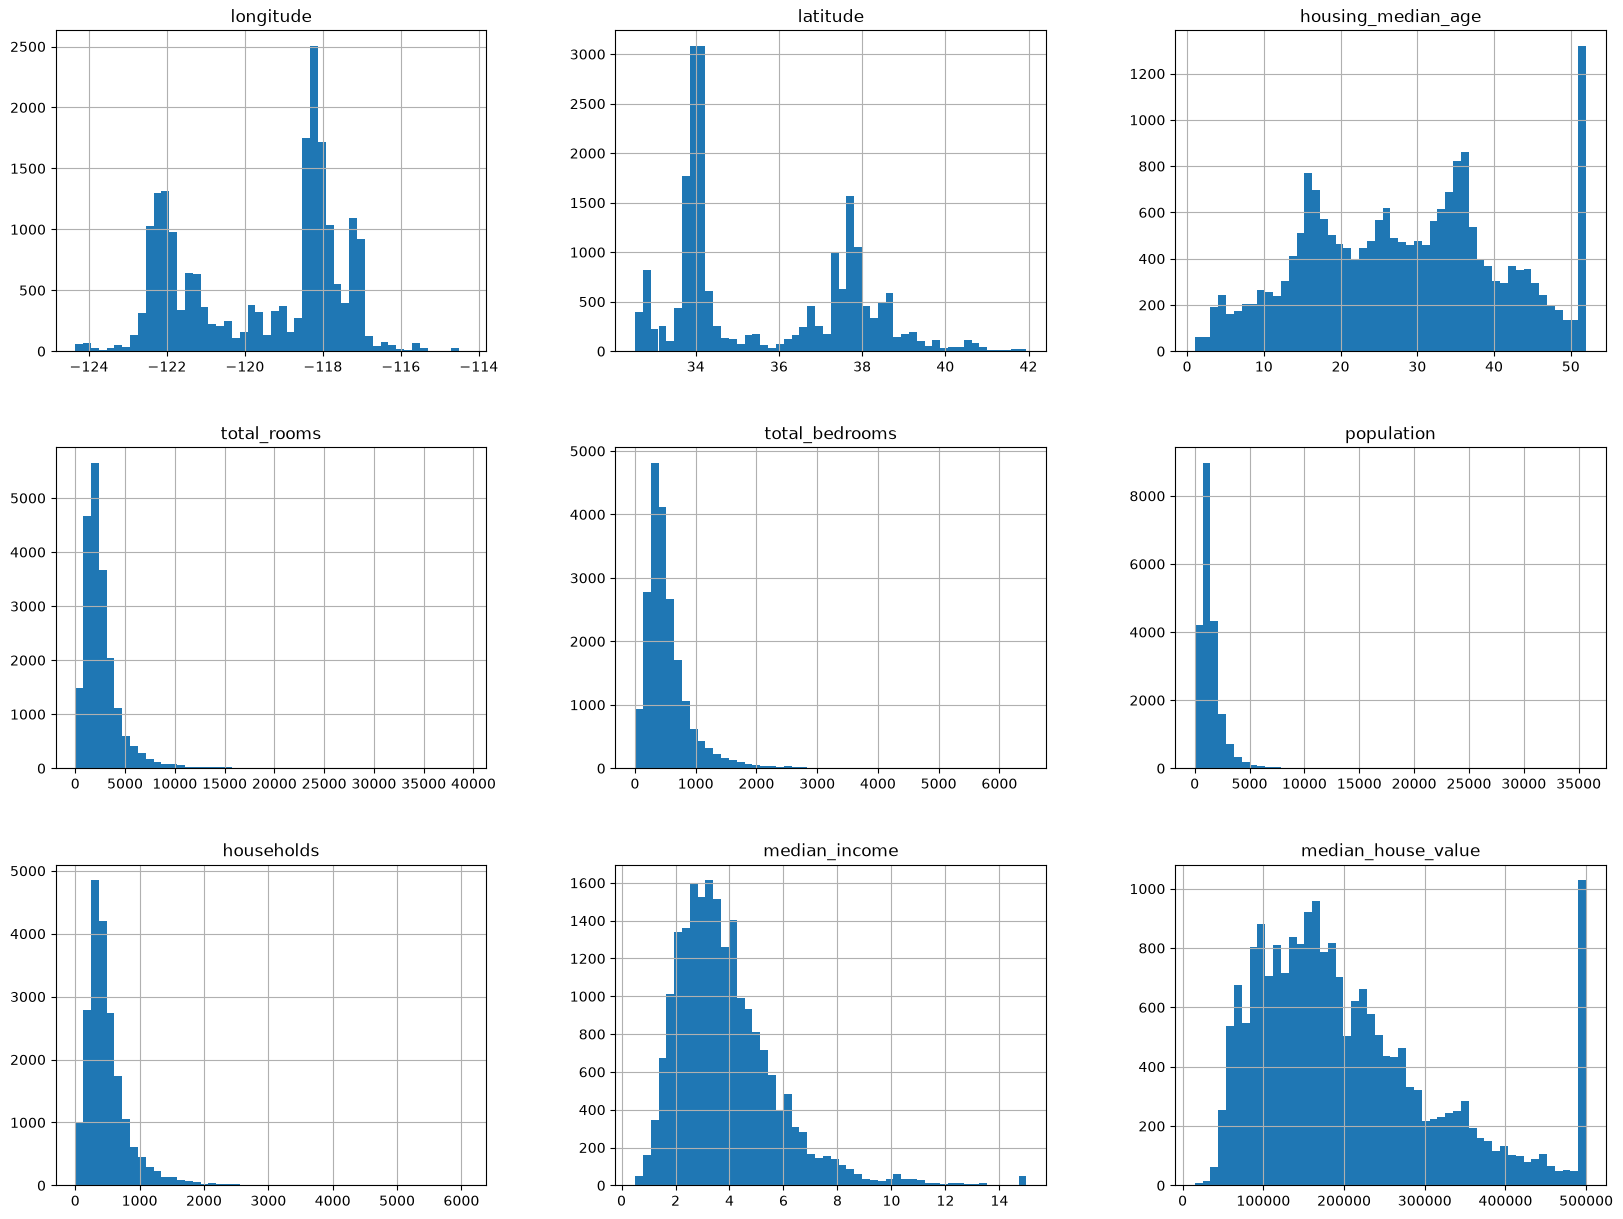

In [9]:
df.hist(bins=50, figsize=(20, 15))
plt.show()

__Define the features and the targets__

In [10]:
X = df.drop('median_house_value', axis=1)
y = df['median_house_value']

__Train and Test data split__

In [11]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [12]:
X.shape, y.shape

((20640, 9), (20640,))

In [13]:
housing = X_train.copy()

__Ploting the Latitude and Longitude__

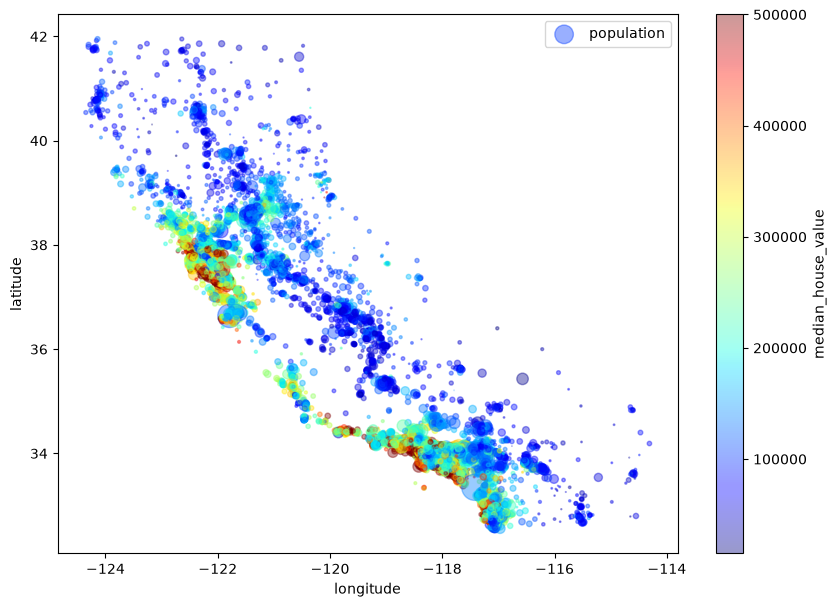

In [14]:
housing = X_train.copy()
housing["median_house_value"] = y_train.values

housing.plot(
    kind="scatter",
    x="longitude",
    y="latitude",
    alpha=0.4,
    s=housing["population"] / 100,
    label="population",
    figsize=(10, 7),
    c="median_house_value",
    cmap=plt.get_cmap("jet"),
    colorbar=True,
)
plt.legend()
plt.show()

__Findings the correlations__

In [15]:
corr_matrix = housing.drop(['ocean_proximity'], axis=1).corr()

In [16]:
corr_matrix['median_house_value'].sort_values(ascending=False)

median_house_value    1.000000
median_income         0.690647
total_rooms           0.133989
housing_median_age    0.103706
households            0.063714
total_bedrooms        0.047980
population           -0.026032
longitude            -0.046349
latitude             -0.142983
Name: median_house_value, dtype: float64

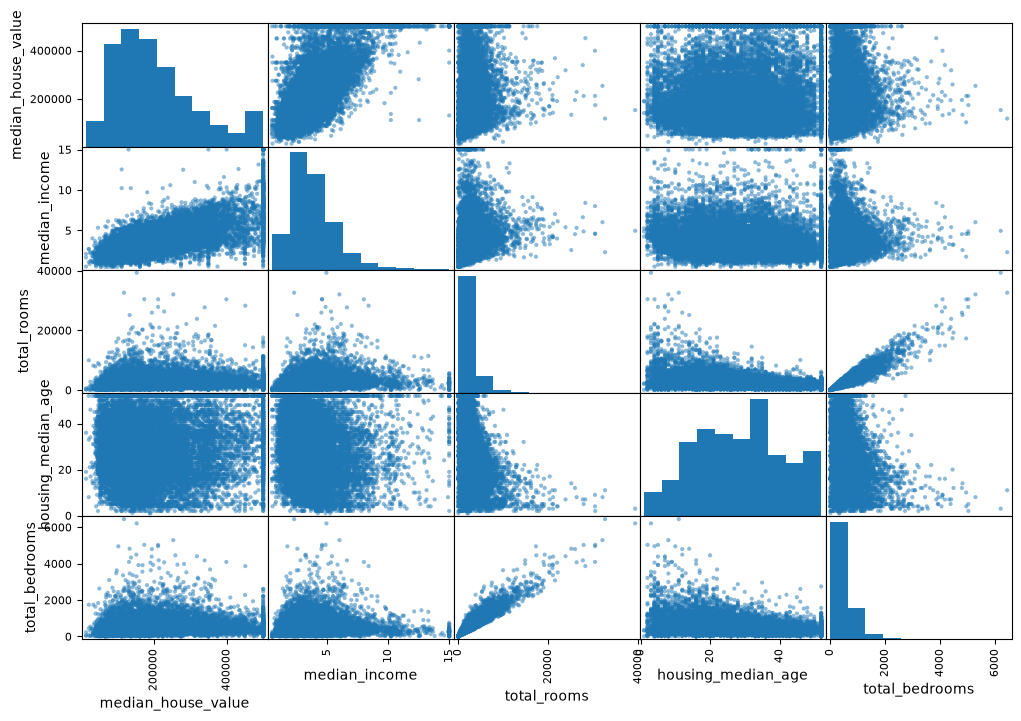

In [17]:
attributes = ['median_house_value', 'median_income', 'total_rooms', 'housing_median_age', 'total_bedrooms']

scatter_matrix(housing[attributes], figsize=(12, 8))
plt.show()

In [18]:
housing['rooms_per_household'] = housing['total_rooms'] / housing['households']
housing['bedrooms_per_room'] = housing['total_bedrooms'] / housing['total_rooms']
housing['population_per_household'] = housing['population'] / housing['households']


In [19]:
# Check the correlations

corr_matrix = housing.drop(['ocean_proximity'], axis=1).corr()
corr_matrix['median_house_value'].sort_values(ascending=False)


median_house_value          1.000000
median_income               0.690647
rooms_per_household         0.158485
total_rooms                 0.133989
housing_median_age          0.103706
households                  0.063714
total_bedrooms              0.047980
population_per_household   -0.022030
population                 -0.026032
longitude                  -0.046349
latitude                   -0.142983
bedrooms_per_room          -0.257419
Name: median_house_value, dtype: float64

__Samples in in each "ocean_proximity" feature__

ocean_proximity
<1H OCEAN     7341
INLAND        5227
NEAR OCEAN    2086
NEAR BAY      1854
ISLAND           4
Name: count, dtype: int64

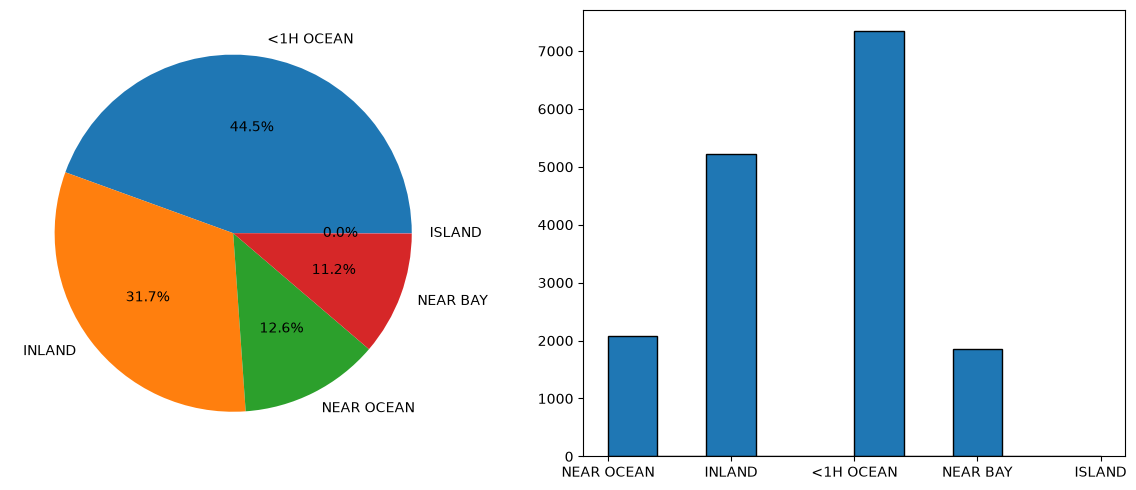

In [20]:
display(housing['ocean_proximity'].value_counts())

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].pie(
    housing['ocean_proximity'].value_counts(),
    labels=housing['ocean_proximity'].value_counts().index,
    autopct='%1.1f%%'
)

axes[1].hist(housing['ocean_proximity'], edgecolor='black')

fig.tight_layout()

plt.show()

__Selected Features V1__

In [21]:

data_v1 = housing.drop(['longitude', 'latitude'], axis=1)

data_v1.sample(5)


,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity,median_house_value,rooms_per_household,bedrooms_per_room,population_per_household
8733,50.0,696.0,311.0,382.0,234.0,2.7750,<1H OCEAN,225000.0,2.974359,0.446839,1.632479
7970,40.0,1699.0,346.0,1188.0,329.0,4.2083,<1H OCEAN,147300.0,5.164134,0.203649,3.610942
2815,35.0,2353.0,483.0,1368.0,455.0,2.3250,INLAND,63200.0,5.171429,0.205270,3.006593
1877,27.0,1492.0,393.0,717.0,254.0,1.8906,INLAND,104200.0,5.874016,0.263405,2.822835
14598,19.0,6823.0,1509.0,3784.0,1509.0,3.1032,NEAR OCEAN,179500.0,4.521537,0.221164,2.507621


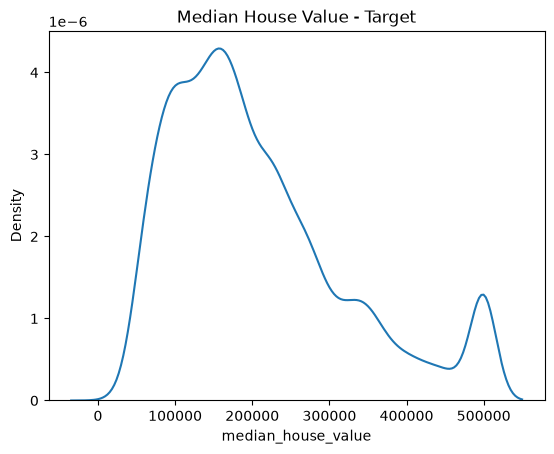

((11558, 10), (4954, 10))

In [22]:
X = data_v1.drop(['median_house_value'], axis=1)
y = data_v1['median_house_value']

sns.kdeplot(data=data_v1, x='median_house_value')
plt.title('Median House Value - Target')
plt.show()


# Scale the target
scaler = StandardScaler()
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=32)

y_train_scaled = scaler.fit_transform(y_train.to_numpy().reshape(-1, 1)).flatten()
y_test_scaled = scaler.transform(y_train.to_numpy().reshape(-1, 1)).flatten()

X_train.shape, X_test.shape


In [23]:
numerical_cols = ['housing_median_age', 'total_rooms', 'total_bedrooms', 'population',
                  'households', 'median_income', 'rooms_per_household', 'bedrooms_per_room',
                  'population_per_household']

reltive_mean_dist_cols = ['housing_median_age', 'median_income']
relative_median_dist_cols = ['total_rooms', 'total_bedrooms', 'population', 'households',
                            'rooms_per_household', 'bedrooms_per_room', 
    'population_per_household']


ordinal_cols = ['ocean_proximity']
ocean_proximity_order = ['<1H OCEAN', 'INLAND', 'NEAR OCEAN', 'NEAR BAY', 'ISLAND']

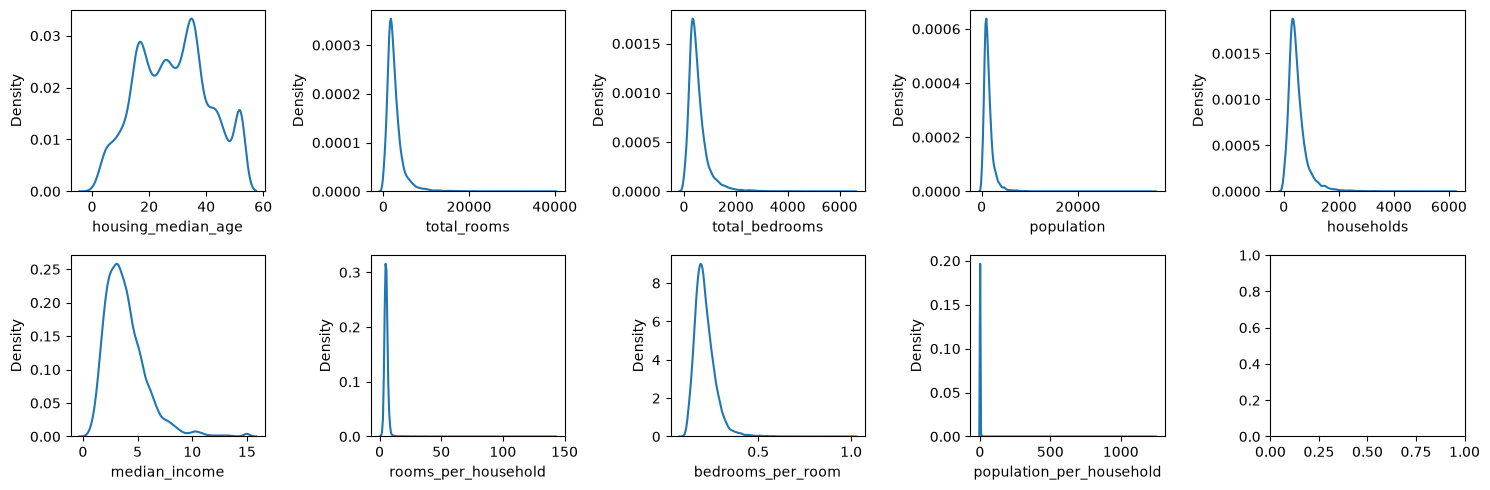

In [24]:
fig, axes = plt.subplots(nrows=2, ncols=5, figsize=(15, 5))
for idx, col in enumerate(numerical_cols):
    sns.kdeplot(data_v1[col], ax=axes[idx//5, idx%5])

fig.tight_layout()
plt.show()


__Test section 1 based on__
* numerical feature will be in StandardScaler
* ordinal features will be in OrdinalEncoder
* __model__ will be `LinearRegression`, `SGDRegressor`


In [25]:
SGD_MAX_ITERS = 10000

linear_reg_model = LinearRegression()
# sgd_reg_model = SGDRegressor(penalty=None, max_iter=SGD_MAX_ITERS, learning_rate="constant")
sgd_reg_model = SGDRegressor(
    loss='squared_error',   # Minimizes Mean Squared Error (Linear Regression)
    penalty='l2',            # L2 regularization (Ridge) to prevent overfitting
    alpha=0.0001,            # Regularization strength
    learning_rate='optimal', # Adaptive learning rate schedule
    max_iter=1000,           # Maximum passes over training data
    tol=1e-3,                # Early stopping threshold
    random_state=42
)


In [26]:

pipeline1_mean_dis  = Pipeline(
    steps=(
        ('imputer', SimpleImputer(strategy='mean')),
        ('scaler', StandardScaler())
    )
)

pipeline2_median_dis = Pipeline(
    steps=(
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', RobustScaler())
    )
)

pipeline3_ordinal = Pipeline(
    steps=(
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', OrdinalEncoder(categories=[ocean_proximity_order]))
    )
)

preprocessing_v1 = ColumnTransformer(
    transformers=(
        ('pi_mean_dist', pipeline1_mean_dis, reltive_mean_dist_cols),
        ('pi_median_dist', pipeline2_median_dis, relative_median_dist_cols),
        ('pi_ordinal', pipeline3_ordinal, ordinal_cols)
    ),
    remainder='passthrough',
    verbose_feature_names_out=False
)


linear_reg_model = Pipeline(
    steps=(
        ('preprocessor', preprocessing_v1),
        ('model', linear_reg_model)
    )
)

sgd_reg_model = Pipeline(
    steps=(
        ('preprocessor', preprocessing_v1),
        ('model', sgd_reg_model)
    )
)


__Train model__

In [27]:

linear_reg_model.fit(X_train, y_train_scaled)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](10,)","['housing_median_age','total_rooms','total_bedrooms',..., 'rooms_per_household','bedrooms_per_room','population_per_household']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,10
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","(('pi_mean_dist', ...), ...)"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will

In [28]:
sgd_reg_model.fit(X_train, y_train_scaled)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](10,)","['housing_median_age','total_rooms','total_bedrooms',..., 'rooms_per_household','bedrooms_per_room','population_per_household']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,10
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","(('pi_mean_dist', ...), ...)"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will

#### Accuracy

In [29]:
from sklearn.metrics import (
    mean_squared_error, r2_score, root_mean_squared_error, mean_absolute_error
)

# lir_y_preds_scaled = linear_reg_model.predict(X_test)
# lir_y_preds = scaler.inverse_transform(lir_y_preds_scaled.reshape(-1, 1)).flatten()
lir_y_preds_scaled = linear_reg_model.predict(X_test)
sgd_y_preds_scaled = sgd_reg_model.predict(X_test)

lir_y_preds = scaler.inverse_transform(lir_y_preds_scaled.reshape(-1, 1)).flatten()
sgd_y_preds = scaler.inverse_transform(sgd_y_preds_scaled.reshape(-1, 1)).flatten()

li_reg_mse = round(mean_squared_error(y_test, lir_y_preds), 4)
li_reg_r2_score = round(r2_score(y_test, lir_y_preds), 4)
li_reg_rmse = round(root_mean_squared_error(y_test, lir_y_preds), 4)
li_reg_mae = round(mean_absolute_error(y_test, lir_y_preds), 4)

sgd_reg_mse = round(mean_squared_error(y_test, sgd_y_preds), 4)
sgd_reg_r2_score = round(r2_score(y_test, sgd_y_preds), 4)
sgd_reg_rmse = round(root_mean_squared_error(y_test, sgd_y_preds), 4)
sgd_reg_mae = round(mean_absolute_error(y_test, sgd_y_preds), 4)


In [30]:
print(f'LinearRegression - MSE: {li_reg_mse}')
print(f'LinearRegression - R2 Score: {li_reg_r2_score}')
print(f'LinearRegression - RMSE: {li_reg_rmse}')
print(f'LinearRegression - MSE: {li_reg_mae}')

LinearRegression - MSE: 5277679385.9687
LinearRegression - R2 Score: 0.5996
LinearRegression - RMSE: 72647.6385
LinearRegression - MSE: 52696.9846


In [31]:
print(f'SGDRegressor - MSE: {sgd_reg_mse}')
print(f'SGDRegressor - R2 Score: {sgd_reg_r2_score}')
print(f'SGDRegressor - RMSE: {sgd_reg_rmse}')
print(f'SGDRegressor - MSE: {sgd_reg_mae}')

SGDRegressor - MSE: 5.005702473101387e+39
SGDRegressor - R2 Score: -3.7979552207634655e+29
SGDRegressor - RMSE: 7.075098920228174e+19
SGDRegressor - MSE: 5.939915784326777e+18


In [32]:

print(linear_reg_model['model'].intercept_)

print(linear_reg_model['model'].coef_)


-0.06824275651745576
[ 0.19970759  0.84623303 -0.05862563  0.00227669 -0.2942525   0.42550788
  0.01676885  0.23234133 -0.00122573  0.01209143]


__We need more hypertuning for SGDRegressor, so apply gradient descent on Linear Regression__

#### Optimization

In [41]:
# Training with Linear Regression

def compute_cost(X, y, W, b):
    m = X.shape[0]
    cost = 0.0

    for i in range(m):
        prediction = np.matmul(W, X[i].transpose()) + b
        error = prediction - y[i]
        error_squared = error ** 2
        cost = cost + error_squared

    cost = cost / (2 * m)

    return cost

def calculate_gradient(X, y, W, b):
    m = X.shape[0]
    dj_dw = np.zeros_like(W)
    dj_db = 0.0

    for i in range(m):
        prediction = np.matmul(W, X[i].transpose()) + b
        error = prediction - y[i]

        dj_dw = dj_dw + (error * X[i])
        dj_db = dj_db + error

    return dj_dw / m, dj_db / m


# Gradient descent
def gradient_descent(X, y, W_input, b_input, max_iter, alpha=0.01):
    W = W_input.copy()
    b = b_input
    costs = []
    iterations = []

    for i in range(max_iter):
        dj_dw, dj_db = calculate_gradient(X, y, W, b)

        # parameter update
        W = W - alpha * dj_dw
        b = b - alpha * dj_db

        # track progress
        cost = compute_cost(X, y, W, b)
        costs.append(cost)
        iterations.append(i)

        if i % 100 == 0:
            print(f"Iteration {i}: Cost {cost:0.4f}, |W|: {W}, b: {b:0.4f}")
    return W, b, costs, iterations

In [51]:
np.zeros(X.shape[1])

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])

In [ ]:
X = linear_reg_model['preprocessor'].transform(X_train)
y = y_train_scaled
W = np.zeros(X.shape[1])
b = 0.0

MAX_ITER = 10000
ALPHA = 0.001

W_final, b_final, costs, iters = gradient_descent(X, y, W, b, max_iter=MAX_ITER, alpha=ALPHA)


Iteration 0: Cost 0.4992, |W|: [ 1.05475681e-04  6.87451178e-04  1.60847219e-04  4.97949985e-05
 -3.77050828e-05  6.76241335e-05  2.40712230e-04 -2.34326493e-04
 -3.92494941e-04  2.84532859e-05], b: 0.0000
Iteration 100: Cost 0.4462, |W|: [ 0.01134415  0.06495477  0.0134409   0.00378484 -0.00462716  0.00565237
  0.01936123 -0.02023742 -0.00170762  0.00242467], b: -0.0003
Iteration 200: Cost 0.4081, |W|: [ 0.02331693  0.12136702  0.02270495  0.00610857 -0.01038094  0.00987647
  0.03073972 -0.0345131  -0.00174346  0.00415452], b: -0.0011
Iteration 300: Cost 0.3792, |W|: [ 0.035432    0.17132909  0.02939676  0.00787358 -0.0165207   0.0135128
  0.03671768 -0.04430461 -0.00177882  0.005476  ], b: -0.0021
Iteration 400: Cost 0.3567, |W|: [ 0.04733544  0.21593028  0.0343691   0.00949202 -0.0226758   0.01692507
  0.03898363 -0.05057173 -0.001813    0.00652886], b: -0.0031
Iteration 500: Cost 0.3385, |W|: [ 0.05881773  0.256024    0.03814174  0.01115066 -0.02868502  0.02027221
  0.0387529  -0.0

In [57]:
W_final

array([ 2.04060669e-01,  8.37916893e-01, -1.40883897e-03,  1.25832107e-01,
       -2.39384445e-01,  1.84703087e-01,  4.43858292e-04,  2.27591291e-01,
       -1.62519971e-03,  1.17448795e-02])

In [58]:
b_final

np.float64(-0.06501154059306616)

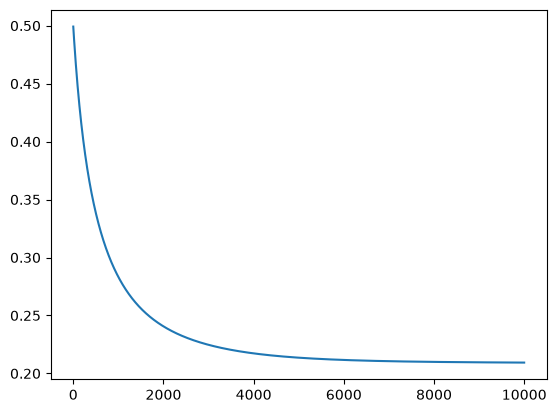

In [59]:
plt.plot(iters, costs)